# Classic model

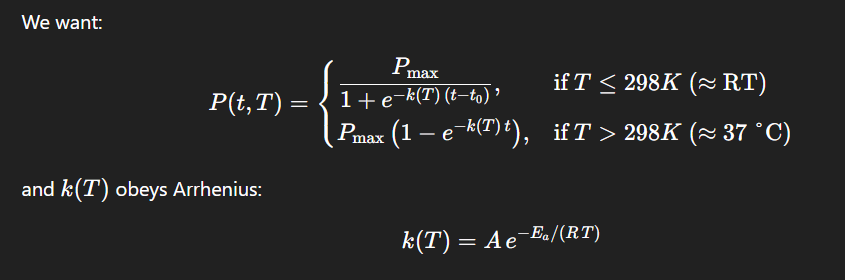

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

In [90]:
# --- Load your wide-format CSV ---
df_wide = pd.read_excel("all_time_temp.xlsx")

# Extract all experiment names automatically from column headers
samples = [col.split("_Time")[0] for col in df_wide.columns if "_Time" in col]

# Build dictionary {sample_name: sub-DataFrame}
datasets = {}
for s in samples:
    time_col = f"{s}_Time"
    temp_col = f"{s}_Temperature"
    subdf = df_wide[[time_col, temp_col]].copy()
    subdf.columns = ["Time (h)", "calibrated temperature (C)"]
    subdf = subdf.dropna().reset_index(drop=True)
    datasets[s] = subdf

print(" Loaded samples:", list(datasets.keys()))


 Loaded samples: ['M1_RT', 'M2_RT', 'M2_37C', 'M3_RT', 'M3_37C', 'M4_37C']


In [106]:

R = 8.314  # J/mol·K

# --- Cell 3: Metadata for each experiment ---

meta = pd.DataFrame({
    "Sample": ["M1_RT", "M2_RT", "M2_37C", "M3_RT", "M3_37C", "M4_37C"],
    "C_mM": [2.5, 2.18, 2.18, 1.2, 1.2, 1.6],
    "V_solution_mL": [6.0]*6,
    "V_head_mL": [4.0]*6,
    "Ea_Jmol": [19999.06, 19999.22, 93554.58,19997.88, 23583.23, 91914.18],  #check this
    "A_ph": [138.63, 178.49, 3.56e14, 252.38, 911.411, 2.45e14 ],  #check this
    "t0_h":[16.55, 62.77, 12.25, 29.25,7.16, 8.65],
    "Yield": [0.91, 0.756, 0.93, 0.902, 0.95, 0.97],
    "Model": ["logistic", "logistic", "first_order", "logistic", "first_order", "first_order"]
})

display(meta)










,Sample,C_mM,V_solution_mL,V_head_mL,Ea_Jmol,A_ph,t0_h,Yield,Model
0,M1_RT,2.50,6.0,4.0,19999.06,1.386300e+02,16.55,0.910,logistic
1,M2_RT,2.18,6.0,4.0,19999.22,1.784900e+02,62.77,0.756,logistic
2,M2_37C,2.18,6.0,4.0,93554.58,3.560000e+14,12.25,0.930,first_order
3,M3_RT,1.20,6.0,4.0,19997.88,2.523800e+02,29.25,0.902,logistic
4,M3_37C,1.20,6.0,4.0,23583.23,9.114110e+02,7.16,0.950,first_order
5,M4_37C,1.60,6.0,4.0,91914.18,2.450000e+14,8.65,0.970,first_order


✅ Global fit: A = 2.117e+02, Ea = 20.3 kJ/mol
   (Used 6 experiments)


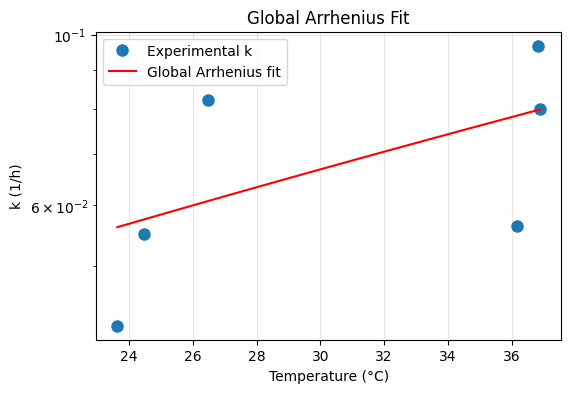

In [ ]:
# # --- Fit Global Arrhenius Parameters ---
# from scipy.optimize import curve_fit

# def arrhenius(T_K, A, Ea):
#     """Arrhenius equation: k = A * exp(-Ea / RT)"""
#     return A * np.exp(-Ea / (R * T_K))

# # Prepare data for fitting
# T_data = []
# k_data = []

# for _, row in meta.iterrows():
#     # Get representative temperature
#     sample_name = row['Sample']
#     df_temp = datasets[sample_name]
#     T_mean = df_temp["calibrated temperature (C)"].mean() + 273.15
    
#     # Get k from metadata (mean k value from your fits)
#     # Use the fitted k or A values you already have
#     if row['Model'] == 'logistic':
#         k_mean = row['A_ph'] * np.exp(-row['Ea_Jmol'] / (R * T_mean))
#     else:
#         k_mean = row['A_ph'] * np.exp(-row['Ea_Jmol'] / (R * T_mean))
    
#     T_data.append(T_mean)
#     k_data.append(k_mean)

# T_data = np.array(T_data)
# k_data = np.array(k_data)

# # Fit global A and Ea
# popt, pcov = curve_fit(arrhenius, T_data, k_data, p0=[1e6, 50000])
# A_global, Ea_global = popt

# print(f"✅ Global fit: A = {A_global:.3e}, Ea = {Ea_global/1000:.1f} kJ/mol")
# print(f"   (Used {len(T_data)} experiments)")

# # Plot to verify
# plt.figure(figsize=(6,4))
# plt.semilogy(T_data - 273.15, k_data, 'o', label='Experimental k', markersize=8)
# T_plot = np.linspace(T_data.min(), T_data.max(), 100)
# plt.semilogy(T_plot - 273.15, arrhenius(T_plot, A_global, Ea_global), 
#              'r-', label='Global Arrhenius fit')
# plt.xlabel('Temperature (°C)')
# plt.ylabel('k (1/h)')
# plt.legend()
# plt.grid(alpha=0.3)
# plt.title('Global Arrhenius Fit')
# plt.show()

In [107]:
# --- Cell 4: Compute dynamic k(T) for each sample --- i.e the arrhenius K
R = 8.314  # J/mol·K

k_dynamic = {}

for s in datasets.keys():
    df = datasets[s].copy()
    meta_row = meta.loc[meta["Sample"] == s].iloc[0]
    
    
    # convert °C → K
    df["T_K"] = df["calibrated temperature (C)"] + 273.15
    
    # dynamic k(t) using Arrhenius
    A = meta_row["A_ph"]
    Ea = meta_row["Ea_Jmol"]
    df["k(1/h)"] = A * np.exp(-Ea / (R * df["T_K"]))
    
    k_dynamic[s] = df
    print(f" Computed k(T) for {s}: range = [{df['k(1/h)'].min():.3e}, {df['k(1/h)'].max():.3e}]")
    
    # After computing df["k(1/h)"]
    k_mean = df["k(1/h)"].mean()  # average k for this sample
    meta.loc[meta["Sample"] == s, "k_fit"] = k_mean

    


 Computed k(T) for M1_RT: range = [4.078e-02, 4.394e-02]
 Computed k(T) for M2_RT: range = [5.323e-02, 5.731e-02]
 Computed k(T) for M2_37C: range = [5.452e-02, 5.725e-02]
 Computed k(T) for M3_RT: range = [7.694e-02, 8.961e-02]
 Computed k(T) for M3_37C: range = [9.603e-02, 9.704e-02]
 Computed k(T) for M4_37C: range = [7.856e-02, 8.373e-02]


In [108]:
display(meta)

,Sample,C_mM,V_solution_mL,V_head_mL,Ea_Jmol,A_ph,t0_h,Yield,Model,k_fit
0,M1_RT,2.50,6.0,4.0,19999.06,1.386300e+02,16.55,0.910,logistic,0.041864
1,M2_RT,2.18,6.0,4.0,19999.22,1.784900e+02,62.77,0.756,logistic,0.055146
2,M2_37C,2.18,6.0,4.0,93554.58,3.560000e+14,12.25,0.930,first_order,0.056484
3,M3_RT,1.20,6.0,4.0,19997.88,2.523800e+02,29.25,0.902,logistic,0.082379
4,M3_37C,1.20,6.0,4.0,23583.23,9.114110e+02,7.16,0.950,first_order,0.096736
5,M4_37C,1.60,6.0,4.0,91914.18,2.450000e+14,8.65,0.970,first_order,0.080017


In [109]:
# Pmax for each sample


Pmax_dict = {}

for s in meta["Sample"]:
    m = meta.loc[meta["Sample"] == s].iloc[0]
    
    # Convert concentration from mM → mol/L
    C_mol_L = m["C_mM"] * 1e-3
    
    # Convert volumes to liters and cubic meters
    V_sol_L = m["V_solution_mL"] * 1e-3
    V_head_L = m["V_head_mL"] * 1e-3
    V_head_m3 = V_head_L * 1e-3  # 1 L = 1e-3 m³
    
    # Use the mean temperature from your dynamic data
    df_temp = datasets[s]
    T_mean_K = (df_temp["calibrated temperature (C)"].mean() + 273.15)
    
    # Calculate moles of O₂ released
    n_mol = C_mol_L * V_sol_L * m["Yield"]
    
    # Ideal gas law: P = nRT / V
    Pmax_Pa = (n_mol * R * T_mean_K) / V_head_m3
    Pmax_kPa = Pmax_Pa / 1000.0
    
    Pmax_dict[s] = Pmax_kPa
    print(f"{s}: Pmax = {Pmax_kPa:.2f} kPa (T_mean = {T_mean_K:.2f} K)")



M1_RT: Pmax = 8.42 kPa (T_mean = 296.78 K)
M2_RT: Pmax = 6.12 kPa (T_mean = 297.62 K)
M2_37C: Pmax = 7.82 kPa (T_mean = 309.31 K)
M3_RT: Pmax = 4.04 kPa (T_mean = 299.62 K)
M3_37C: Pmax = 4.41 kPa (T_mean = 309.98 K)
M4_37C: Pmax = 6.00 kPa (T_mean = 310.04 K)


In [110]:
# --- Cell 6: Simulate P(t) for each sample --- (pressure at each time point)

from scipy.integrate import cumulative_trapezoid

results = {}

for s in datasets.keys():
    df = k_dynamic[s]
    m = meta.loc[meta["Sample"] == s].iloc[0]
    
    time = df["Time (h)"].values
    kT = df["k(1/h)"].values
    Pmax = Pmax_dict[s]
    
    if m["Model"] == "logistic":
        # Logistic growth: P = Pmax / (1 + exp(-∫k dt))
        t0 = m["t0_h"]
        K_int = cumulative_trapezoid(kT, time, initial=0)
        P = Pmax / (1 + np.exp(-K_int*(time - t0)))
        
    elif m["Model"] == "first_order":
        # First-order release: P = Pmax * (1 - exp(-∫k dt))
        K_int = cumulative_trapezoid(kT, time, initial=0)
        P = Pmax * (1 - np.exp(-K_int))
        
    else:
        raise ValueError(f"Unknown model type for {s}")
    
    df["P_predicted"] = P
    results[s] = df

    print(f" Simulated P(t) for {s} ({m['Model']})")


 Simulated P(t) for M1_RT (logistic)
 Simulated P(t) for M2_RT (logistic)
 Simulated P(t) for M2_37C (first_order)
 Simulated P(t) for M3_RT (logistic)
 Simulated P(t) for M3_37C (first_order)
 Simulated P(t) for M4_37C (first_order)


In [ ]:
# --- Cell 7: Plot ---
import matplotlib.pyplot as plt

for s, df in results.items():
    m = meta.loc[meta["Sample"] == s].iloc[0]
    plt.figure(figsize=(6,4))
    plt.plot(df["Time (h)"], df["P_predicted"], label=f"{s} ({m['Model']})", lw=2)
    plt.xlabel("Time (h)")
    plt.ylabel("Predicted Pressure / O₂ released (relative)")
    plt.title(f"Classical model prediction — {s}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()



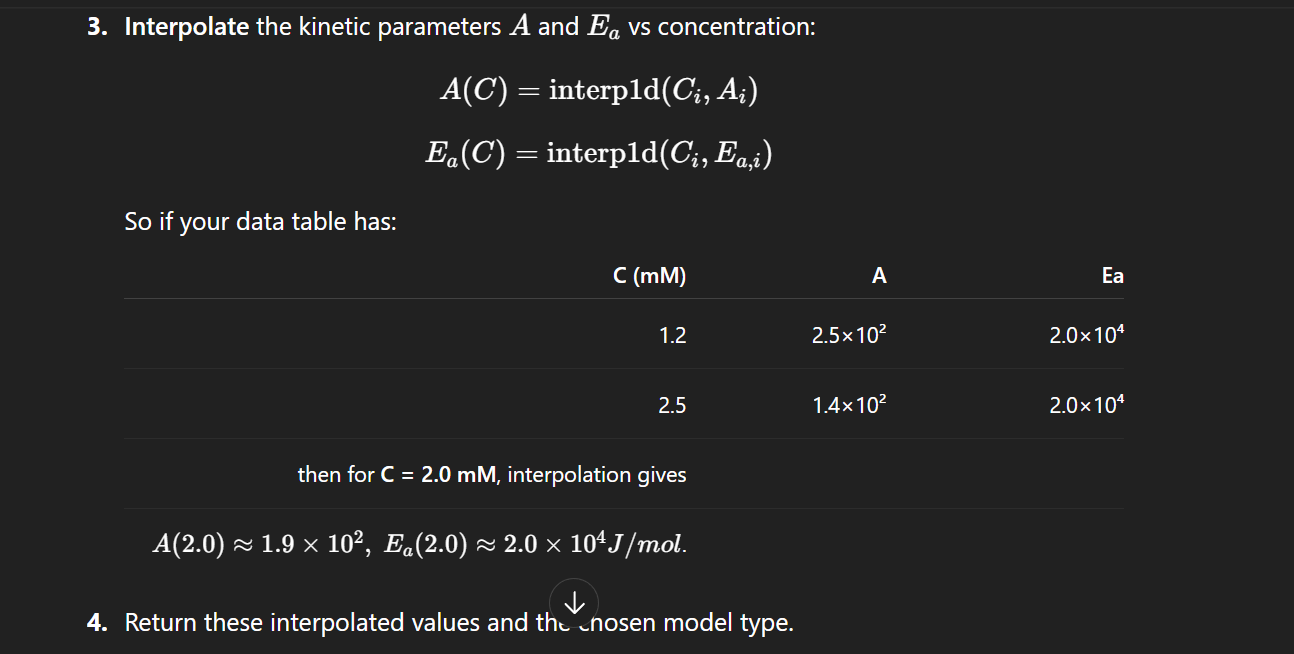](attachment:image.png)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from scipy.interpolate import interp1d
from scipy.stats import linregress


R = 8.314  # J/mol·K


def get_params_for_temp(temp_C, conc_mM, meta):
    """
    Select the nearest experiment's A and Ea from the meta DataFrame
    based on user temperature (Celsius).
    """
    
    model_temp_map = {
        "logistic": 25.0,
        "first_order": 37.0
    }

    # Compute distance of user temperature from each model type
    "If temperature is near 25 °C, choose logistic, If closer to 37 °C, choose first-order"
    d_logistic = abs(temp_C - model_temp_map["logistic"])
    d_first = abs(temp_C - model_temp_map["first_order"])

    # Choose the closest model type
    model_type = "logistic" if d_logistic < d_first else "first_order"

    # Get the row from your real meta table (flowed logic, i cannot just use the logistic 1st mathc or first order first match everytime)
    # row = meta[meta["Model"] == model_type].iloc[0]
    # A = row["A_ph"]
    # Ea = row["Ea_Jmol"]

    #Instead of averaging, it now interpolates t0 based on known data → higher concentrations generally have smaller t0
    sub_meta = meta[meta["Model"] == model_type]
    interp_A = interp1d(sub_meta["C_mM"], sub_meta["A_ph"], fill_value='extrapolate')  #CHANGED TO  NEAREST INTERP INSTEAD OF LINEAR
    interp_Ea = interp1d(sub_meta["C_mM"], sub_meta["Ea_Jmol"], fill_value='extrapolate')

    A = float(interp_A(conc_mM))
    Ea = float(interp_Ea(conc_mM))
    return A, Ea, model_type



# main simulation function
def simulate_classical(conc_mM, temp_C):
    #  Automatically choose parameters based on temperature
    A, Ea, model_choice = get_params_for_temp(temp_C, conc_mM, meta)
    
    if model_choice == "logistic":  
        sub_meta = meta[meta["Model"] == "logistic"]
        interp_t0 = interp1d(sub_meta["C_mM"], sub_meta["t0_h"], fill_value='extrapolate') #CHANGED TO  NEAREST INTERP INSTEAD OF LINEAR
        t0 = float(interp_t0(conc_mM))
    else:
        t0 = 0 

    # Fixed geometry
    V_sol_L = 0.006   # 6 mL solution
    V_head_L = 0.004  # 4 mL headspace
    Yield = 0.9

    # Unit conversions
    C_mol_L = conc_mM * 1e-3
    V_head_m3 = V_head_L * 1e-3
    T_K = temp_C + 273.15
    
    # Warn about extrapolation
    if temp_C < 20 or temp_C > 40:
        print(f" Extrapolating beyond tested range (20-40°C)")
    if conc_mM < 1.0 or conc_mM > 2.5:
        print(f" Extrapolating beyond tested conc range (1.0-2.5 mM)")

    # Calculate k with concentration dependence
    def arrhenius(T_K, A, Ea):
      return A * np.exp(-Ea / (R * T_K))


    k_base = arrhenius(T_K, A, Ea)
    
    # # ADD THIS: Concentration dependence (power law)
    # C_ref = 2.0  # Reference concentration (mM) - middle of your range
    # n_conc = 0.5  # Concentration order (adjust based on your data)
    
    #k dependence on conc has been made dynamic instead of hardcoding
    sub_meta = meta[meta["Model"] == model_choice]
    logC = np.log(sub_meta["C_mM"])
    logk = np.log(sub_meta["k_fit"])

    slope, intercept, _, _, _ = linregress(logC, logk)
    n_conc = slope                   # concentration order
    C_ref = meta["C_mM"].mean()      # set reference dynamically
    


    k = k_base * (conc_mM / C_ref)**n_conc  # ← ADDED concentration dependence, This makes k depend on both temperature and concentration → k(T,C).

    #  Compute Pmax in kPa
    n_mol = C_mol_L * V_sol_L * Yield
    Pmax_Pa = (n_mol * R * T_K) / V_head_m3
    Pmax_kPa = Pmax_Pa / 1000.0

    #  Simulate P(t)
    t = np.linspace(0, 250, 1000)   # extend to 250 h
    if model_choice == "logistic":
        P = Pmax_kPa / (1 + np.exp(-k * (t - t0)))  
    else:
        P = Pmax_kPa * (1 - np.exp(-k * t))

    
    # Convert Pressure → µmol O₂
    R_Latm = 0.082057  # L·atm/mol·K
    pressure_atm = P / 101.325  # convert kPa → atm
    o2_umol = ((pressure_atm * V_head_L) / (R_Latm * T_K)) * 1e6  # µmol O₂

    
    ratio = V_sol_L / V_head_L

   
    fig, ax1 = plt.subplots(figsize=(7, 4))
    ax1.plot(t, P, lw=2, color="tab:blue", label="Pressure (kPa)")
    ax1.set_xlabel("Time (h)")
    ax1.set_ylabel("Pressure (kPa)", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    ax2 = ax1.twinx()
    ax2.plot(t, o2_umol, lw=2, color="tab:red", linestyle="--", label="O2 released (µmol)")
    ax2.set_ylabel("O2 released (µmol)", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    plt.title(f"Predicted P(t) and O2(t) — {model_choice.capitalize()} model @ {temp_C:.1f}°C")
    fig.tight_layout()
    plt.show()

  
    print(f"Model selected: {model_choice}")
    print(f"A = {A:.3e}, Ea = {Ea/1000:.1f} kJ/mol, t₀ = {t0:.2f} h")
    print(f"k(T) = {k:.3e} 1/h, Pmax = {Pmax_kPa:.2f} kPa")
    print(f"Predicted max O2 = {max(o2_umol):.2f} µmol")
    
 
interact(
    simulate_classical,
    conc_mM=FloatSlider(value=2.0, min=0.5, max=5.0, step=0.1, description="Conc (mM)"),
    temp_C=FloatSlider(value=25.0, min=20.0, max=45.0, step=0.5, description="Temp (°C)")
);


interactive(children=(FloatSlider(value=2.0, description='Conc (mM)', max=5.0, min=0.5), FloatSlider(value=25.…

C:\Users\chand\AppData\Local\Temp\ipykernel_9656\3577797011.py:9: RuntimeWarning: overflow encountered in exp
  return Pmax / (1 + np.exp(-k * (t - t0)))
C:\Users\chand\AppData\Local\Temp\ipykernel_9656\3577797011.py:12: RuntimeWarning: overflow encountered in exp
  return Pmax * (1 - np.exp(-k * t))
C:\Users\chand\AppData\Local\Temp\ipykernel_9656\3577797011.py:12: RuntimeWarning: overflow encountered in multiply
  return Pmax * (1 - np.exp(-k * t))
C:\Users\chand\AppData\Local\Temp\ipykernel_9656\3577797011.py:66: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_log, _ = curve_fit(logistic_func, t, P, maxfev=20000)
C:\Users\chand\AppData\Local\Temp\ipykernel_9656\3577797011.py:74: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_first, _ = curve_fit(first_order_func, t, P, maxfev=20000)
C:\Users\chand\AppData\Local\Temp\ipykernel_9656\3577797011.py:52: RuntimeWarning: overflow encountered in exp
  P = Pmax_kPa * (1 - np.exp(-k * t

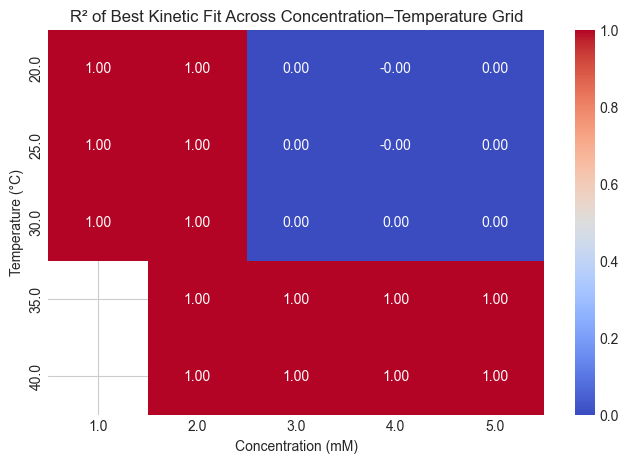

C:\Users\chand\AppData\Local\Temp\ipykernel_9656\3577797011.py:105: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pivot_numeric = pivot_model.replace(model_to_num)


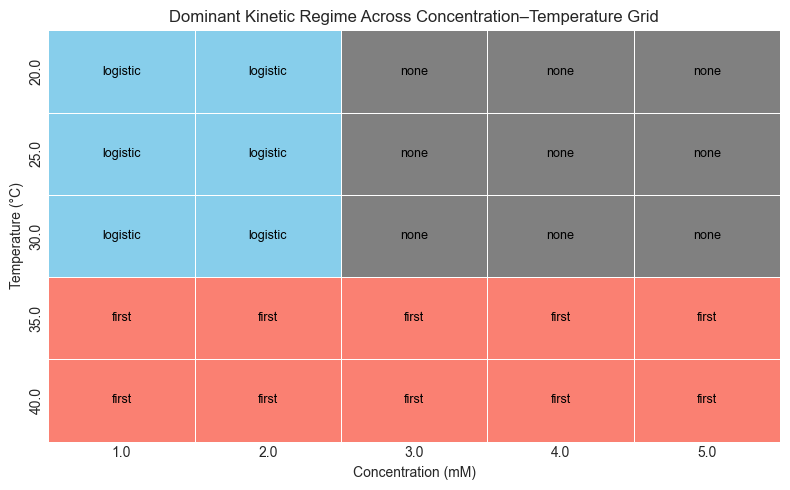

    Temp_C  C_mM        R2_log  R2_first       R2_best Best_model
0     20.0   1.0  1.000000e+00  0.951669  1.000000e+00   logistic
1     20.0   2.0  1.000000e+00  0.953156  1.000000e+00   logistic
2     20.0   3.0  0.000000e+00 -0.041189  0.000000e+00       none
3     20.0   4.0 -4.218847e-14 -0.015626 -4.218847e-14       none
4     20.0   5.0  2.220446e-16 -0.005887  2.220446e-16       none
5     25.0   1.0  1.000000e+00  0.937699  1.000000e+00   logistic
6     25.0   2.0  1.000000e+00  0.937135  1.000000e+00   logistic
7     25.0   3.0  2.220446e-16 -0.055326  2.220446e-16       none
8     25.0   4.0 -5.604406e-13 -0.012992 -5.604406e-13       none
9     25.0   5.0  0.000000e+00 -0.005542  0.000000e+00       none
10    30.0   1.0  1.000000e+00  0.923184  1.000000e+00   logistic
11    30.0   2.0  1.000000e+00  0.920412  1.000000e+00   logistic
12    30.0   3.0  0.000000e+00 -0.078159  0.000000e+00       none
13    30.0   4.0  1.110223e-16 -0.011071  1.110223e-16       none
14    30.0

In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns

# --- Define helper kinetic functions ---
def logistic_func(t, Pmax, k, t0):
    return Pmax / (1 + np.exp(-k * (t - t0)))

def first_order_func(t, Pmax, k):
    return Pmax * (1 - np.exp(-k * t))

def compute_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

# --- Modified simulate function (returns data, not plots) ---
def simulate_classical_return(conc_mM, temp_C):
    A, Ea, model_choice = get_params_for_temp(temp_C, conc_mM, meta)
    if model_choice == "logistic":
        sub_meta = meta[meta["Model"] == "logistic"]
        interp_t0 = interp1d(sub_meta["C_mM"], sub_meta["t0_h"], fill_value='extrapolate')
        t0 = float(interp_t0(conc_mM))
    else:
        t0 = 0 

    V_sol_L, V_head_L, Yield = 0.006, 0.004, 0.9
    C_mol_L = conc_mM * 1e-3
    V_head_m3 = V_head_L * 1e-3
    T_K = temp_C + 273.15

    def arrhenius(T_K, A, Ea): return A * np.exp(-Ea / (R * T_K))
    k_base = arrhenius(T_K, A, Ea)

    sub_meta = meta[meta["Model"] == model_choice]
    logC, logk = np.log(sub_meta["C_mM"]), np.log(sub_meta["k_fit"])
    slope, intercept, _, _, _ = linregress(logC, logk)
    n_conc = slope
    C_ref = meta["C_mM"].mean()
    k = k_base * (conc_mM / C_ref)**n_conc

    n_mol = C_mol_L * V_sol_L * Yield
    Pmax_Pa = (n_mol * R * T_K) / V_head_m3
    Pmax_kPa = Pmax_Pa / 1000.0

    t = np.linspace(0, 250, 1000)
    if model_choice == "logistic":
        P = Pmax_kPa / (1 + np.exp(-k * (t - t0)))
    else:
        P = Pmax_kPa * (1 - np.exp(-k * t))
    return t, P

# --- Scan grid of conditions ---
temps = np.linspace(20, 40, 5)  
concs = np.linspace(1.0, 5.0, 5)  # 1 to 4 mM
results = []

for T in temps:
    for C in concs:
        t, P = simulate_classical_return(C, T)

        # Fit logistic model
        try:
            popt_log, _ = curve_fit(logistic_func, t, P, maxfev=20000)
            P_fit_log = logistic_func(t, *popt_log)
            r2_log = compute_r2(P, P_fit_log)
        except:
            r2_log = np.nan

        # Fit first-order model
        try:
            popt_first, _ = curve_fit(first_order_func, t, P, maxfev=20000)
            P_fit_first = first_order_func(t, *popt_first)
            r2_first = compute_r2(P, P_fit_first)
        except:
            r2_first = np.nan

        results.append({"Temp_C": T, "C_mM": C, "R2_log": r2_log, "R2_first": r2_first})

df_val = pd.DataFrame(results)

# --- Determine "best-fit" type ---
df_val["R2_best"] = df_val[["R2_log", "R2_first"]].max(axis=1)
df_val["Best_model"] = np.where(df_val["R2_log"] > df_val["R2_first"], "logistic", "first")
df_val.loc[df_val["R2_best"] < 0.8, "Best_model"] = "none"

# --- Plot 1: Heatmap of overall fit quality ---
pivot = df_val.pivot_table(values="R2_best", index="Temp_C", columns="C_mM")
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, cmap="coolwarm", vmin=0, vmax=1, annot=True, fmt=".2f")
plt.title("R² of Best Kinetic Fit Across Concentration–Temperature Grid")
plt.xlabel("Concentration (mM)")
plt.ylabel("Temperature (°C)")
plt.show()

# --- Plot 2: Model classification map ---
# --- Plot 2: Model classification map (fixed version) ---
# Map text categories to numbers for heatmap
model_to_num = {"logistic": 1, "first": 2, "none": 0}
num_to_model = {0: "none", 1: "logistic", 2: "first"}

pivot_model = df_val.pivot_table(values="Best_model", index="Temp_C", columns="C_mM", aggfunc=lambda x: x.iloc[0])
pivot_numeric = pivot_model.replace(model_to_num)

plt.figure(figsize=(8, 5))
ax = sns.heatmap(
    pivot_numeric,
    cmap=sns.color_palette(["grey", "skyblue", "salmon"]),
    cbar=False,
    linewidths=0.5,
    linecolor="white"
)

# Add readable labels on top of cells
for y in range(pivot_model.shape[0]):
    for x in range(pivot_model.shape[1]):
        label = pivot_model.iloc[y, x]
        ax.text(x + 0.5, y + 0.5, label, color="black", ha="center", va="center", fontsize=9)

plt.title("Dominant Kinetic Regime Across Concentration–Temperature Grid")
plt.xlabel("Concentration (mM)")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()


# --- Summary output ---
print(df_val)



# Try choosing instead of interpolatimg A, try scaling with concentration based on k or A ( look inro how it works after making ppt)

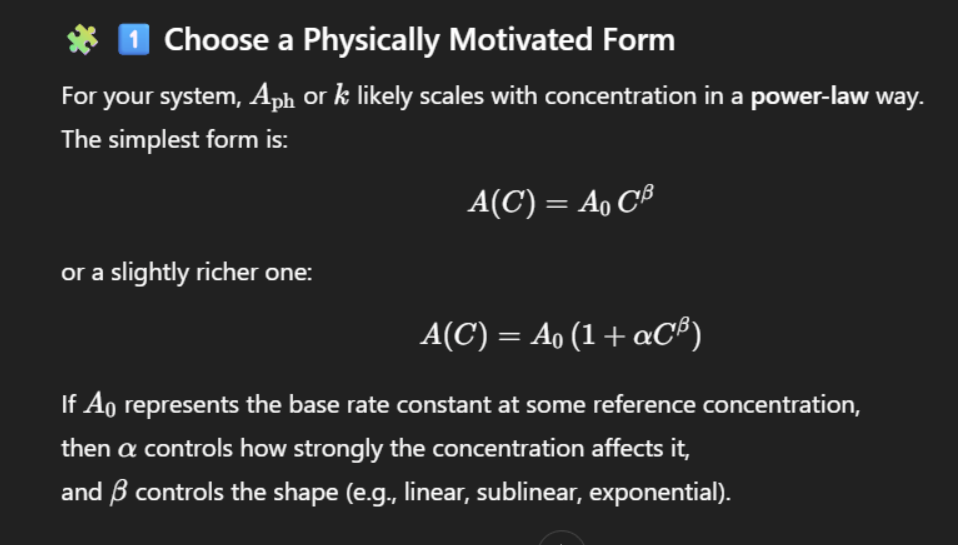

c:\Users\chand\Documents\GitHub\Thesis\thesis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


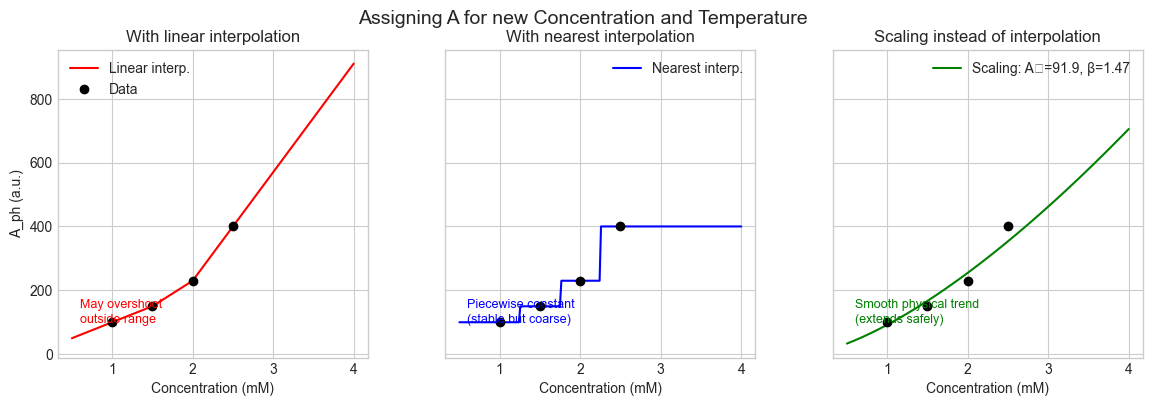

In [114]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- Synthetic "experimental" data ---
C = np.array([1.0, 1.5, 2.0, 2.5])      # concentration (mM)
A = np.array([100, 150, 230, 400])      # pre-exponential factor (arbitrary units)

# --- Target range for visualization ---
C_new = np.linspace(0.5, 4.0, 200)

# --- Linear interpolation (extrapolation allowed) ---
f_linear = interp1d(C, A, kind='linear', fill_value='extrapolate')
A_linear = f_linear(C_new)

# --- Nearest interpolation ---
f_nearest = interp1d(C, A, kind='nearest', fill_value='extrapolate')
A_nearest = f_nearest(C_new)

# --- Scaling / power-law model ---
# Fit a simple power law: A = A0 * C^beta
logC, logA = np.log(C), np.log(A)
beta, logA0 = np.polyfit(logC, logA, 1)
A0 = np.exp(logA0)
A_scale = A0 * C_new**beta

# --- Plot ---
fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
plt.subplots_adjust(wspace=0.25)

# Linear
axs[0].plot(C_new, A_linear, 'r-', label='Linear interp.')
axs[0].plot(C, A, 'ko', label='Data')
axs[0].set_title("With linear interpolation")
axs[0].text(0.6, 100, "May overshoot\noutside range", fontsize=9, color='red')
axs[0].set_xlabel("Concentration (mM)")
axs[0].set_ylabel("A_ph (a.u.)")
axs[0].legend()

# Nearest
axs[1].plot(C_new, A_nearest, 'b-', label='Nearest interp.')
axs[1].plot(C, A, 'ko')
axs[1].set_title("With nearest interpolation")
axs[1].text(0.6, 100, "Piecewise constant\n(stable but coarse)", fontsize=9, color='blue')
axs[1].set_xlabel("Concentration (mM)")
axs[1].legend()

# Scaling
axs[2].plot(C_new, A_scale, 'g-', label=f"Scaling: A₀={A0:.1f}, β={beta:.2f}")
axs[2].plot(C, A, 'ko')
axs[2].set_title("Scaling instead of interpolation")
axs[2].text(0.6, 100, "Smooth physical trend\n(extends safely)", fontsize=9, color='green')
axs[2].set_xlabel("Concentration (mM)")
axs[2].legend()

plt.suptitle("Assigning A for new Concentration and Temperature", fontsize=14)
plt.show()


# Mention the fact tyhat different bounds were used for logistic for 1.2mM RT

it is to be noted that the k value should have a limit like it works welll from bound -.1 (see if there are different testuig technqiues for it) (previously i kept 1e6 as the bound for k but it didnt give good results, explore into this)

drawbacks :
1. Interpolation for temperature beyond the tested limited is unreliable: is there a fix for this with kinetic modelling? if no, what could be done?

# Prove empirically that kinetic models (first-order, logistic, Arrhenius–logistic) are insufficient to accurately estimate P(t,T) across time, temperature, and concentration variations.

# t0 vs conc at RT

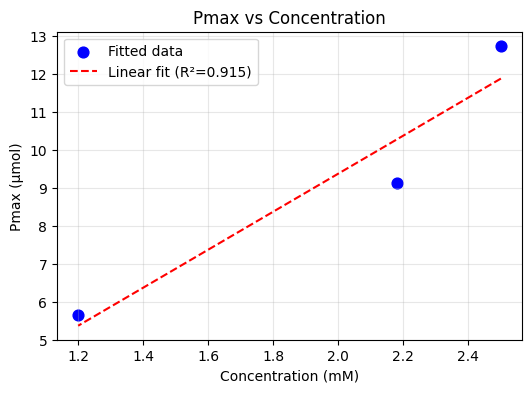

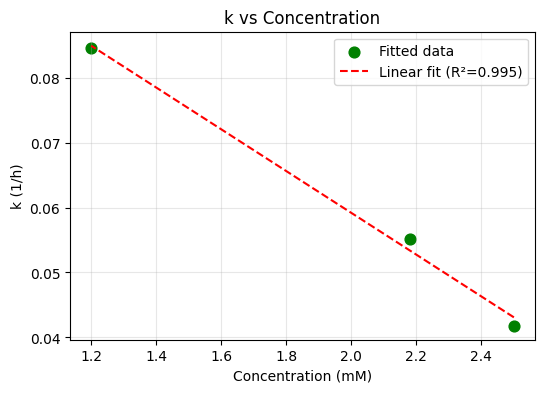

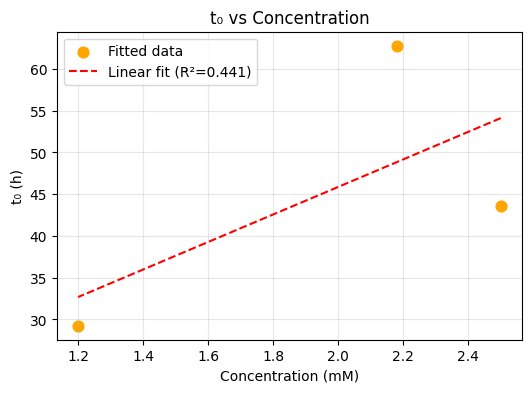

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ---------------------------
# Example fitted parameters from your runs
# Replace with actual values from your logistic/Arrhenius fits
# ---------------------------
data = {
    "Sample": ["M1", "M2", "M3"],
    "Conc_mM": [2.5, 2.18, 1.2],
    "Pmax_umol": [12.744, 9.128, 5.65],
    "k_mean_1h": [0.0418, 0.0551, 0.0845],
    "t0_h": [43.60, 62.77, 29.25],
}

df = pd.DataFrame(data)

# ---------------------------
# Plot 1: Pmax vs Concentration
# ---------------------------
plt.figure(figsize=(6, 4))
plt.scatter(df["Conc_mM"], df["Pmax_umol"], s=60, c='b', label="Fitted data")
plt.xlabel("Concentration (mM)")
plt.ylabel("Pmax (µmol)")
plt.title("Pmax vs Concentration")
# Linear fit test
model = LinearRegression().fit(df[["Conc_mM"]], df["Pmax_umol"])
pred = model.predict(df[["Conc_mM"]])
r2 = r2_score(df["Pmax_umol"], pred)
plt.plot(df["Conc_mM"], pred, "r--", label=f"Linear fit (R²={r2:.3f})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ---------------------------
# Plot 2: k vs Concentration
# ---------------------------
plt.figure(figsize=(6, 4))
plt.scatter(df["Conc_mM"], df["k_mean_1h"], s=60, c='g', label="Fitted data")
plt.xlabel("Concentration (mM)")
plt.ylabel("k (1/h)")
plt.title("k vs Concentration")
model = LinearRegression().fit(df[["Conc_mM"]], df["k_mean_1h"])
pred = model.predict(df[["Conc_mM"]])
r2 = r2_score(df["k_mean_1h"], pred)
plt.plot(df["Conc_mM"], pred, "r--", label=f"Linear fit (R²={r2:.3f})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ---------------------------
# Plot 3: t0 vs Concentration
# ---------------------------
plt.figure(figsize=(6, 4))
plt.scatter(df["Conc_mM"], df["t0_h"], s=60, c='orange', label="Fitted data")
plt.xlabel("Concentration (mM)")
plt.ylabel("t₀ (h)")
plt.title("t₀ vs Concentration")
model = LinearRegression().fit(df[["Conc_mM"]], df["t0_h"])
pred = model.predict(df[["Conc_mM"]])
r2 = r2_score(df["t0_h"], pred)
plt.plot(df["Conc_mM"], pred, "r--", label=f"Linear fit (R²={r2:.3f})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


The middle concentration (2.18 mM) has the longest lag phase, which contradicts simple kinetic theory.

# t0 vs conc at 37C

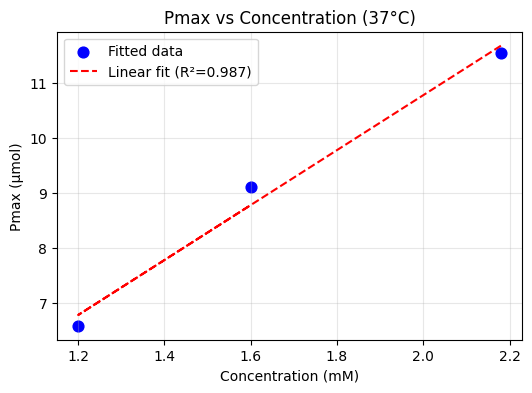

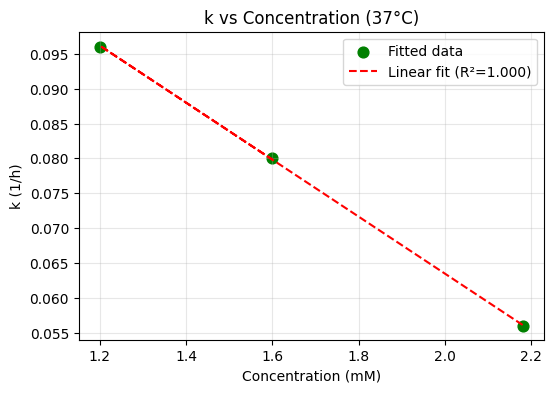

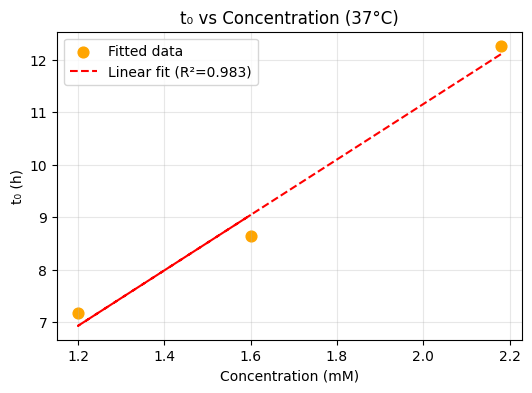

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ---------------------------------------------------------
# Example fitted results at 37 °C (replace with your real fitted values)
# ---------------------------------------------------------
data_37C = {
    "Sample": ["M2", "M3", "M4"],
    "Conc_mM": [2.18, 1.2, 1.6],
    "Pmax_umol": [11.55, 6.58, 9.11],
    "k_mean_1h": [0.056, 0.096, 0.080077],
    "t0_h": [12.27, 7.17, 8.65]
}

df37 = pd.DataFrame(data_37C)

# ---------------------------------------------------------
# Plot 1: Pmax vs Concentration
# ---------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.scatter(df37["Conc_mM"], df37["Pmax_umol"], s=60, c='b', label="Fitted data")
plt.xlabel("Concentration (mM)")
plt.ylabel("Pmax (µmol)")
plt.title("Pmax vs Concentration (37°C)")
# Linear regression
model = LinearRegression().fit(df37[["Conc_mM"]], df37["Pmax_umol"])
pred = model.predict(df37[["Conc_mM"]])
r2 = r2_score(df37["Pmax_umol"], pred)
plt.plot(df37["Conc_mM"], pred, "r--", label=f"Linear fit (R²={r2:.3f})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ---------------------------------------------------------
# Plot 2: k vs Concentration
# ---------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.scatter(df37["Conc_mM"], df37["k_mean_1h"], s=60, c='g', label="Fitted data")
plt.xlabel("Concentration (mM)")
plt.ylabel("k (1/h)")
plt.title("k vs Concentration (37°C)")
model = LinearRegression().fit(df37[["Conc_mM"]], df37["k_mean_1h"])
pred = model.predict(df37[["Conc_mM"]])
r2 = r2_score(df37["k_mean_1h"], pred)
plt.plot(df37["Conc_mM"], pred, "r--", label=f"Linear fit (R²={r2:.3f})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ---------------------------------------------------------
# Plot 3: t0 vs Concentration
# ---------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.scatter(df37["Conc_mM"], df37["t0_h"], s=60, c='orange', label="Fitted data")
plt.xlabel("Concentration (mM)")
plt.ylabel("t₀ (h)")
plt.title("t₀ vs Concentration (37°C)")
model = LinearRegression().fit(df37[["Conc_mM"]], df37["t0_h"])
pred = model.predict(df37[["Conc_mM"]])
r2 = r2_score(df37["t0_h"], pred)
plt.plot(df37["Conc_mM"], pred, "r--", label=f"Linear fit (R²={r2:.3f})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


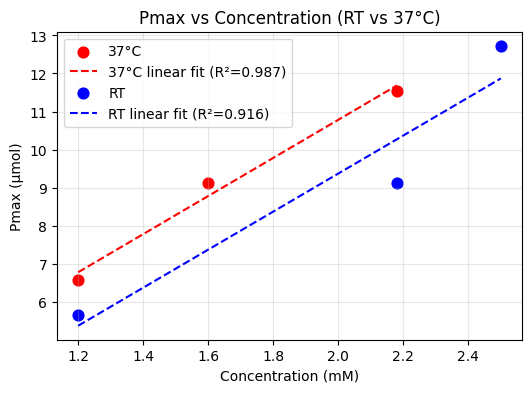

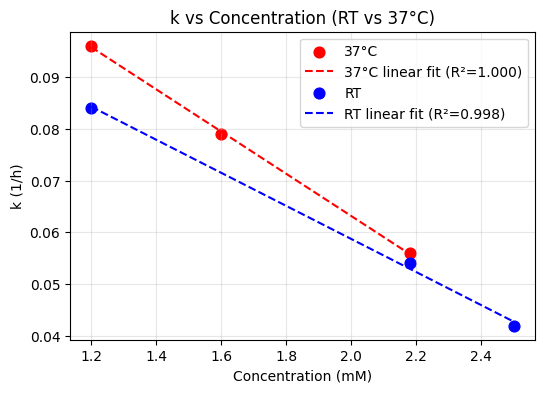

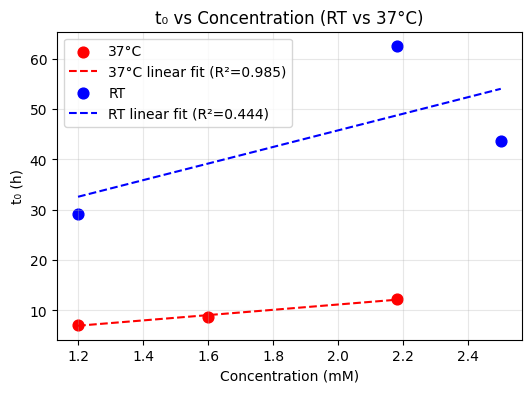

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ---- RT data (from your earlier RT fits) ----
data_RT = {
    "Conc_mM": [1.2, 2.18, 2.5],
    "Pmax_umol": [5.65, 9.13, 12.73],
    "k_mean_1h": [0.084, 0.054, 0.042],
    "t0_h": [29.17, 62.59, 43.59]
}
df_RT = pd.DataFrame(data_RT)
df_RT["Temp"] = "RT"

# ---- 37°C data (from your 37°C fits) ----
data_37C = {
    "Conc_mM": [1.2, 1.6, 2.18],
    "Pmax_umol": [6.58, 9.11, 11.55],
    "k_mean_1h": [0.096, 0.079, 0.056],
    "t0_h": [7.17, 8.70, 12.27]
}
df_37 = pd.DataFrame(data_37C)
df_37["Temp"] = "37°C"

# Combine
df_all = pd.concat([df_RT, df_37])

# ---- Helper for plotting ----
def plot_compare(x, y, ylabel, title):
    plt.figure(figsize=(6,4))
    colors = {"RT": "blue", "37°C": "red"}

    for temp, group in df_all.groupby("Temp"):
        plt.scatter(group["Conc_mM"], group[y], s=60, c=colors[temp], label=temp)
        model = LinearRegression().fit(group[["Conc_mM"]], group[y])
        pred = model.predict(group[["Conc_mM"]])
        r2 = r2_score(group[y], pred)
        plt.plot(group["Conc_mM"], pred, "--", color=colors[temp], 
                 label=f"{temp} linear fit (R²={r2:.3f})")

    plt.xlabel("Concentration (mM)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# ---- Generate comparison plots ----
plot_compare("Conc_mM", "Pmax_umol", "Pmax (µmol)", "Pmax vs Concentration (RT vs 37°C)")
plot_compare("Conc_mM", "k_mean_1h", "k (1/h)", "k vs Concentration (RT vs 37°C)")
plot_compare("Conc_mM", "t0_h", "t₀ (h)", "t₀ vs Concentration (RT vs 37°C)")


# Next plan : 
Train a small MLP (or even a Random Forest) on features:
[t, T, conc] → P(t)

Compare its RMSE and R2 against your logistic model.
Model prediction (classical vs ML) vs experiment.



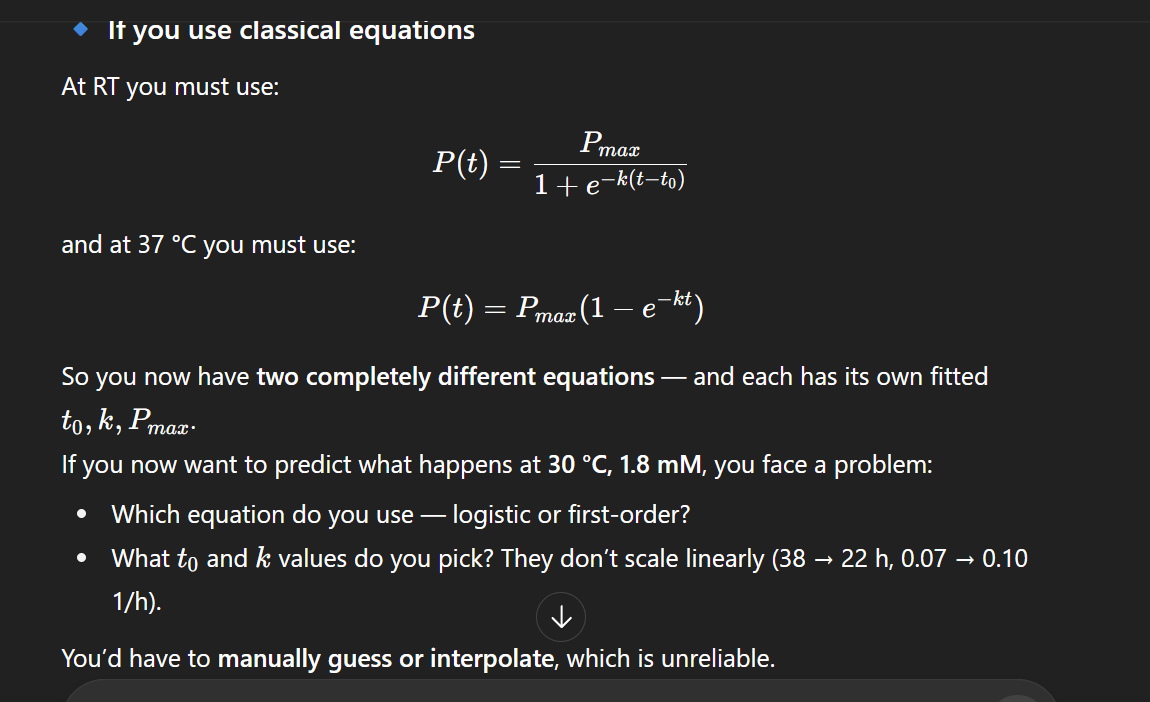

# Predictive extrapolation - temperature domain test

# Using LOOCV